# Proyecto de Grado: IA al servicio de las comunidades
Maestría en Analítica para la Inteligencia de Negocios

**Nombres:** María Fernanda Izquierdo Aparicio & Ana María Ochoa Muñoz

**Fecha:** 18 de Mayo de 2025

Este modelo forma parte del proyecto de grado de la Maestría en Analítica para la Inteligencia de Negocios de la Pontificia Universidad Javeriana, enfocado en la aplicación de Inteligencia Artificial al servicio de las comunidades. Su objetivo es clasificar imágenes de plantas en función de su especie usando una arquitectura pre-entrenada UNet

## 1. Importe de librerias

In [4]:
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

import os
import zipfile
import shutil
!pip install seaborn
import seaborn as sns
import datetime
!pip install opencv-python
import cv2


import keras
from keras import models
from keras import layers

import random

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras import Layer
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Conv2D, MaxPooling2D, UpSampling2D, concatenate, GlobalAveragePooling2D

!pip install scikit-learn

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

from PIL import Image  # Librería para abrir y manipular imágenes

# ignoring warnings
import warnings
warnings.simplefilter("ignore")

In [5]:
#Medir_tiempo_ejecucion():
inicio = datetime.datetime.now()
print(f"Inicio: {inicio.strftime('%Y-%m-%d %H:%M:%S.%f')}")

Inicio: 2025-05-18 10:12:57.357810


## 2. Definción de Rutas y Parámetros

In [7]:
data_dir = 'Datos Finales Estado Balanceados'  # Reemplaza con la ruta real
metadata_file = 'archivos_datos_balanceados_estado.csv' # Reemplaza con la ruta real
image_height = 128
image_width = 128
batch_size = 15
num_classes = None  # Se determinará automáticamente del archivo CSV

## 3. Cargar y procesar los metadatos

In [9]:
try:
    metadata = pd.read_csv(metadata_file, sep=";")
    metadata = metadata.rename(columns={'Nombre del archivo': 'image_id'})
    metadata = metadata.rename(columns={'Planta_Estado': 'Planta_Estado_Español'})
    
    # Asegúrate de que las columnas 'filename' (o el nombre de tu columna de nombres de archivo)
    # y 'label' (o el nombre de tu columna de etiquetas) existan.
   
    if 'image_id' not in metadata.columns or 'Planta_Estado_Español' not in metadata.columns:
        raise ValueError("El archivo CSV debe contener las columnas 'image_id' y 'Planta_Estado_Español'.")
    class_names = metadata['Planta_Estado_Español'].unique().tolist()
    num_classes = len(class_names)
    print(f"Se encontraron {num_classes} clases: {class_names}")
except FileNotFoundError:
    print(f"Error: No se encontró el archivo de metadatos en '{metadata_file}'.")
    exit()
except ValueError as e:
    print(f"Error al procesar el archivo CSV: {e}")
    exit()

Se encontraron 18 clases: ['Maíz_Enferma', 'Tomate_Saludable', 'Yuca_Enferma', 'Pepino Cohombro_Enferma', 'Tomate_Enferma', 'Manzana_Saludable', 'Fresa_Enferma', 'Maíz_Saludable', 'Papa_Enferma', 'Fresa_Saludable', 'Coliflor_Enferma', 'Pepino Cohombro_Saludable', 'Yuca_Saludable', 'Fríjol_Enferma', 'Papa_Saludable', 'Fríjol_Saludable', 'Coliflor_Saludable', 'Manzana_Enferma']


In [10]:
metadata.Planta_Estado_Español.value_counts()

Planta_Estado_Español
Fríjol_Saludable             3501
Maíz_Enferma                 3500
Tomate_Saludable             3500
Coliflor_Saludable           3500
Papa_Saludable               3500
Fríjol_Enferma               3500
Yuca_Saludable               3500
Pepino Cohombro_Saludable    3500
Coliflor_Enferma             3500
Fresa_Saludable              3500
Papa_Enferma                 3500
Maíz_Saludable               3500
Fresa_Enferma                3500
Manzana_Saludable            3500
Tomate_Enferma               3500
Pepino Cohombro_Enferma      3500
Yuca_Enferma                 3500
Manzana_Enferma              3500
Name: count, dtype: int64

In [11]:
train, test= train_test_split(metadata, test_size=0.2, random_state=42,shuffle=True, stratify=metadata['Planta_Estado_Español'])
train.shape, test.shape

((50400, 7), (12601, 7))

In [12]:
train.head()

,Carpeta,image_id,Planta_Inglés,Estado_Ingles,Planta_Español,Estado_Español,Planta_Estado_Español
50219,Potato_healthy,aug_966_683b04ad-7941-4819-9965-ba32c725eb22__...,Potato,healthy,Papa,Saludable,Papa_Saludable
12719,Cucumber_sick,aug_60_cucumber_photo_2020-06-27_23-51-02 (2).jpg,Cucumber,sick,Pepino Cohombro,Enferma,Pepino Cohombro_Enferma
23065,Strawberry_sick,aug_124_36bc7257-0b59-45a9-a692-1ff35b5a3425__...,Strawberry,sick,Fresa,Enferma,Fresa_Enferma
42154,Cassava_healthy,aug_799_919479322.jpg,Cassava,healthy,Yuca,Saludable,Yuca_Saludable
60493,Apple_sick,b1a2c1e8-e1a6-4d25-9d5b-1488e9d8b0ee___FREC_C....,Apple,sick,Manzana,Enferma,Manzana_Enferma


In [13]:
sample = train.sample(5)  # ejemplo común

In [14]:
print(sample.columns)

Index(['Carpeta', 'image_id', 'Planta_Inglés', 'Estado_Ingles',
       'Planta_Español', 'Estado_Español', 'Planta_Estado_Español'],
      dtype='object')


## 4. Crear un generador de datos

In [16]:
# Crear el generador de imágenes
datagen = ImageDataGenerator(
    validation_split = 0.2,
    rescale=1./255,
    preprocessing_function = None,
    rotation_range = 45,
    zoom_range = 0.2,
    horizontal_flip = True,
    vertical_flip = True,
    fill_mode = 'nearest',
    shear_range = 0.1,
    height_shift_range = 0.1,
    width_shift_range = 0.1
)

train_generator = datagen.flow_from_dataframe(
    dataframe=train,
    directory=data_dir,
    x_col='image_id',
    y_col='Planta_Estado_Español',
    target_size=(image_height, image_width),
    batch_size=batch_size,
    class_mode='categorical',  # Importante para clasificación multiclase
    subset='training',
    seed=42,
    classes=class_names  # Asegurarse del orden de las clases
)

validation_generator = datagen.flow_from_dataframe(
    dataframe=train,
    directory=data_dir,
    x_col='image_id',
    y_col='Planta_Estado_Español',
    target_size=(image_height, image_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    seed=42,
    classes=class_names
)

Found 40320 validated image filenames belonging to 18 classes.
Found 10079 validated image filenames belonging to 18 classes.


In [17]:
print(train['Planta_Estado_Español'].value_counts())
print(f"Total clases: {train['Planta_Estado_Español'].nunique()}")


Planta_Estado_Español
Papa_Saludable               2800
Pepino Cohombro_Enferma      2800
Tomate_Saludable             2800
Papa_Enferma                 2800
Maíz_Saludable               2800
Fríjol_Enferma               2800
Coliflor_Enferma             2800
Pepino Cohombro_Saludable    2800
Fríjol_Saludable             2800
Manzana_Saludable            2800
Coliflor_Saludable           2800
Yuca_Enferma                 2800
Tomate_Enferma               2800
Fresa_Saludable              2800
Manzana_Enferma              2800
Yuca_Saludable               2800
Fresa_Enferma                2800
Maíz_Enferma                 2800
Name: count, dtype: int64
Total clases: 18


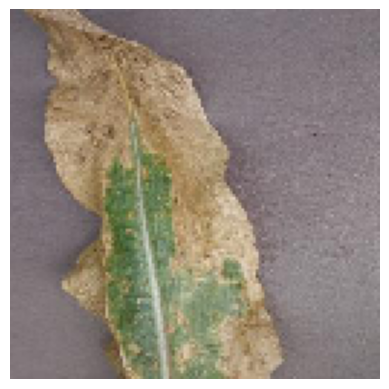

In [18]:
from tensorflow.keras.preprocessing import image
import os
import numpy as np

img_path = os.path.join(data_dir, metadata["image_id"][20])
img = image.load_img(img_path, target_size=(image_height, image_width))
img_tensor = image.img_to_array(img)
img_tensor = np.expand_dims(img_tensor, axis=0)
img_tensor /= 255.

plt.imshow(img_tensor[0])
plt.axis('off')
plt.show()

## 5. Definición del modelo U-Net para clasificación

In [20]:
# DEFINIR EL MODELO U-NET MODIFICADO PARA CLASIFICACIÓN
def unet_classification_model(input_shape=(image_height, image_width, 3), num_classes=num_classes):
    inputs = Input(shape=input_shape)

    # Encoder
    c1 = Conv2D(32, 3, activation='relu', padding='same')(inputs)
    c1 = Conv2D(32, 3, activation='relu', padding='same')(c1)
    p1 = MaxPooling2D()(c1)

    c2 = Conv2D(64, 3, activation='relu', padding='same')(p1)
    c2 = Conv2D(64, 3, activation='relu', padding='same')(c2)
    p2 = MaxPooling2D()(c2)

    c3 = Conv2D(128, 3, activation='relu', padding='same')(p2)
    c3 = Conv2D(128, 3, activation='relu', padding='same')(c3)
    p3 = MaxPooling2D()(c3)

    # Bottleneck
    c4 = Conv2D(256, 3, activation='relu', padding='same')(p3)
    c4 = Conv2D(256, 3, activation='relu', padding='same')(c4)

    # Decoder
    u5 = UpSampling2D()(c4)
    u5 = concatenate([u5, c3])
    c5 = Conv2D(128, 3, activation='relu', padding='same')(u5)
    c5 = Conv2D(128, 3, activation='relu', padding='same')(c5)

    u6 = UpSampling2D()(c5)
    u6 = concatenate([u6, c2])
    c6 = Conv2D(64, 3, activation='relu', padding='same')(u6)
    c6 = Conv2D(64, 3, activation='relu', padding='same')(c6)

    u7 = UpSampling2D()(c6)
    u7 = concatenate([u7, c1])
    c7 = Conv2D(32, 3, activation='relu', padding='same')(u7)
    c7 = Conv2D(32, 3, activation='relu', padding='same')(c7)

    # Clasificación
    gap = GlobalAveragePooling2D()(c7)
    outputs = Dense(num_classes, activation='softmax')(gap)

    model = Model(inputs=inputs, outputs=outputs)
    return model


# CREAR Y COMPILAR EL MODELO
model = unet_classification_model(input_shape=(image_height, image_width, 3), num_classes=num_classes)
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()  # Muestra la arquitectura


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │    147,584 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │    295,168 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16,    │    590,080 │ conv2d_6[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 32, 32,    │          0 │ conv2d_7[0][0]    │
│ (UpSampling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32,    │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 384)              │            │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 32, 32,    │    442,496 │ concatenate[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 32, 32,    │    147,584 │ conv2d_8[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 64, 64,    │          0 │ conv2d_9[0][0]  

 Total params: 1,947,442 (7.43 MB)

 Trainable params: 1,947,442 (7.43 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# Earlystopping
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',     # Monitorea la pérdida en validación
    patience=5,             # Número de épocas sin mejora antes de detener
    restore_best_weights=True,  # Restaura los mejores pesos
    verbose=1
)

## 6. Entrenamiento del Modelo

In [42]:
#Entrenamiento
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    steps_per_epoch=len(train_generator),
    validation_steps=len(validation_generator),
    callbacks=[early_stop]
)


Epoch 1/10
2688/2688 ━━━━━━━━━━━━━━━━━━━━ 3474s 1s/step - accuracy: 0.5217 - loss: 1.3471 - val_accuracy: 0.7689 - val_loss: 0.6385
Epoch 2/10
2688/2688 ━━━━━━━━━━━━━━━━━━━━ 3835s 1s/step - accuracy: 0.7892 - loss: 0.5842 - val_accuracy: 0.8404 - val_loss: 0.4223
Epoch 3/10
2688/2688 ━━━━━━━━━━━━━━━━━━━━ 3747s 1s/step - accuracy: 0.8400 - loss: 0.4351 - val_accuracy: 0.8290 - val_loss: 0.4551
Epoch 4/10
2688/2688 ━━━━━━━━━━━━━━━━━━━━ 3697s 1s/step - accuracy: 0.8579 - loss: 0.3727 - val_accuracy: 0.8865 - val_loss: 0.3057
Epoch 5/10
2688/2688 ━━━━━━━━━━━━━━━━━━━━ 3666s 1s/step - accuracy: 0.8732 - loss: 0.3331 - val_accuracy: 0.8754 - val_loss: 0.3272
Epoch 6/10
2688/2688 ━━━━━━━━━━━━━━━━━━━━ 3658s 1s/step - accuracy: 0.8778 - loss: 0.3200 - val_accuracy: 0.8665 - val_loss: 0.3551
Epoch 7/10
2688/2688 ━━━━━━━━━━━━━━━━━━━━ 3677s 1s/step - accuracy: 0.8940 - loss: 0.2807 - val_accuracy: 0.8941 - val_loss: 0.2841
Epoch 8/10
2688/2688 ━━━━━━━━━━━━━━━━━━━━ 3697s 1s/step - accuracy: 0.9022 -

In [46]:
# Guardar modelo completo (arquitectura + pesos + configuración optimizer)
model.save('modelo_unet_planta_estado.h5')
print("Modelo guardado exitosamente en formato .h5")

Modelo guardado exitosamente en formato .h5


In [48]:
fin = datetime.datetime.now()
print(f"Fin: {fin.strftime('%Y-%m-%d %H:%M:%S.%f')}")
    
duracion = fin - inicio
print(f"Duración: {duracion}")

Fin: 2025-05-18 20:42:57.452580
Duración: 10:30:00.094770


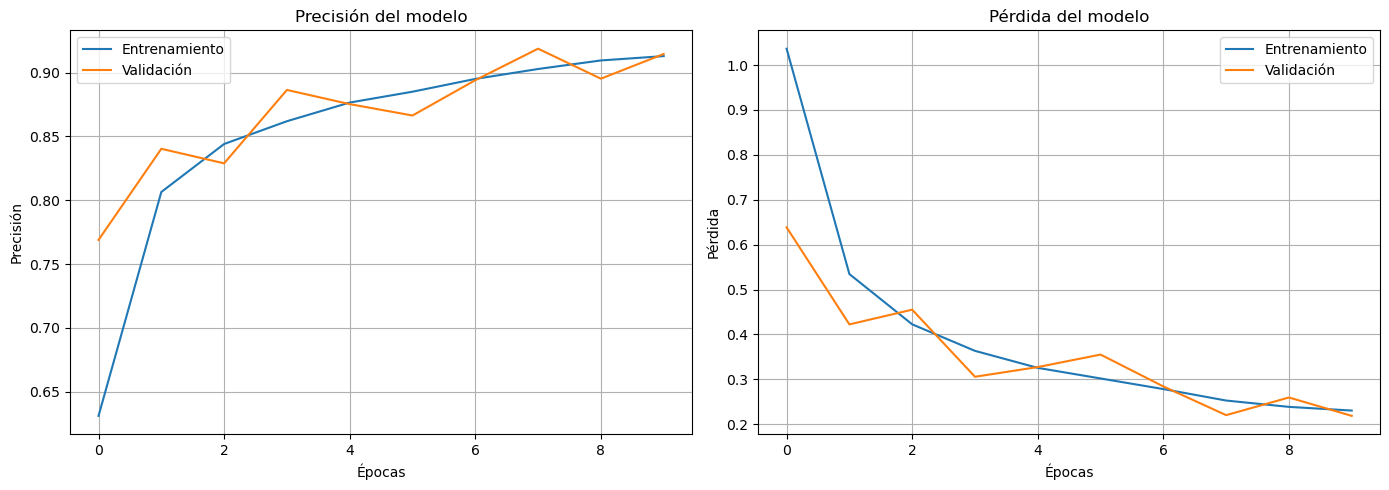

In [50]:
import matplotlib.pyplot as plt

# 1. Crear la figura
plt.figure(figsize=(14, 5))

# 2. Gráfico de Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión del modelo')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True)

# 3. Gráfico de Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida del modelo')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)

# 4. Mostrar
plt.tight_layout()
plt.show()


In [52]:
print(test.columns.tolist())

['Carpeta', 'image_id', 'Planta_Inglés', 'Estado_Ingles', 'Planta_Español', 'Estado_Español', 'Planta_Estado_Español']


In [58]:
epochs = list(range(1, 11))

loss = history.history['loss']
val_loss = history.history['val_loss']
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']


data = {
    'Epoch': epochs,
    'Trainning Loss': loss,
    'Validation Loss': val_loss,
    'Training Accuracy': accuracy,
    'Validation  Accuracy': val_accuracy
}
df = pd.DataFrame(data)

# Imprimir la tabla
print(df)

   Epoch  Trainning Loss  Validation Loss  Training Accuracy  \
0      1        1.036512         0.638510           0.630977   
1      2        0.534451         0.422318           0.806498   
2      3        0.422443         0.455064           0.844122   
3      4        0.363358         0.305653           0.861979   
4      5        0.325465         0.327247           0.876612   
5      6        0.301859         0.355078           0.885119   
6      7        0.278231         0.284074           0.895139   
7      8        0.252673         0.220143           0.902927   
8      9        0.238556         0.259459           0.909623   
9     10        0.230358         0.218538           0.913021   

   Validation  Accuracy  
0              0.768925  
1              0.840361  
2              0.828951  
3              0.886497  
4              0.875384  
5              0.866455  
6              0.894136  
7              0.918841  
8              0.895327  
9              0.914674  


In [66]:
print('Perdida final en Train:', history.history['loss'][-1])
print("Pérdida final en Validation:", history.history['val_loss'][-1])

print("Accuracy final en Train:", history.history['accuracy'][-1])
print("Accuracy final en Validation:", history.history['val_accuracy'][-1])

Perdida final en Train: 0.23035815358161926
Pérdida final en Validation: 0.21853753924369812
Accuracy final en Train: 0.9130208492279053
Accuracy final en Validation: 0.9146741032600403


In [69]:
#validación con datos de test

test_generator =  datagen.flow_from_dataframe(test,
                         directory = "Datos Finales",
                         subset = "training",
                         x_col = "image_id",
                         y_col = "Planta_Estado_Español",
                         target_size = (image_height,image_width),
                         batch_size = batch_size,
                         class_mode = "categorical")


Found 3923 validated image filenames belonging to 18 classes.


## 7. Testeo del Modelo

In [71]:
# Evaluar sobre el set de test
test_loss, test_accuracy = model.evaluate(test_generator, steps=len(test_generator))

print(f'🔎 Pérdida en test: {test_loss:.4f}')
print(f'✅ Precisión en test: {test_accuracy:.2%}')


262/262 ━━━━━━━━━━━━━━━━━━━━ 89s 341ms/step - accuracy: 0.0023 - loss: 25.7195
🔎 Pérdida en test: 25.5258
✅ Precisión en test: 0.28%


262/262 ━━━━━━━━━━━━━━━━━━━━ 93s 354ms/step


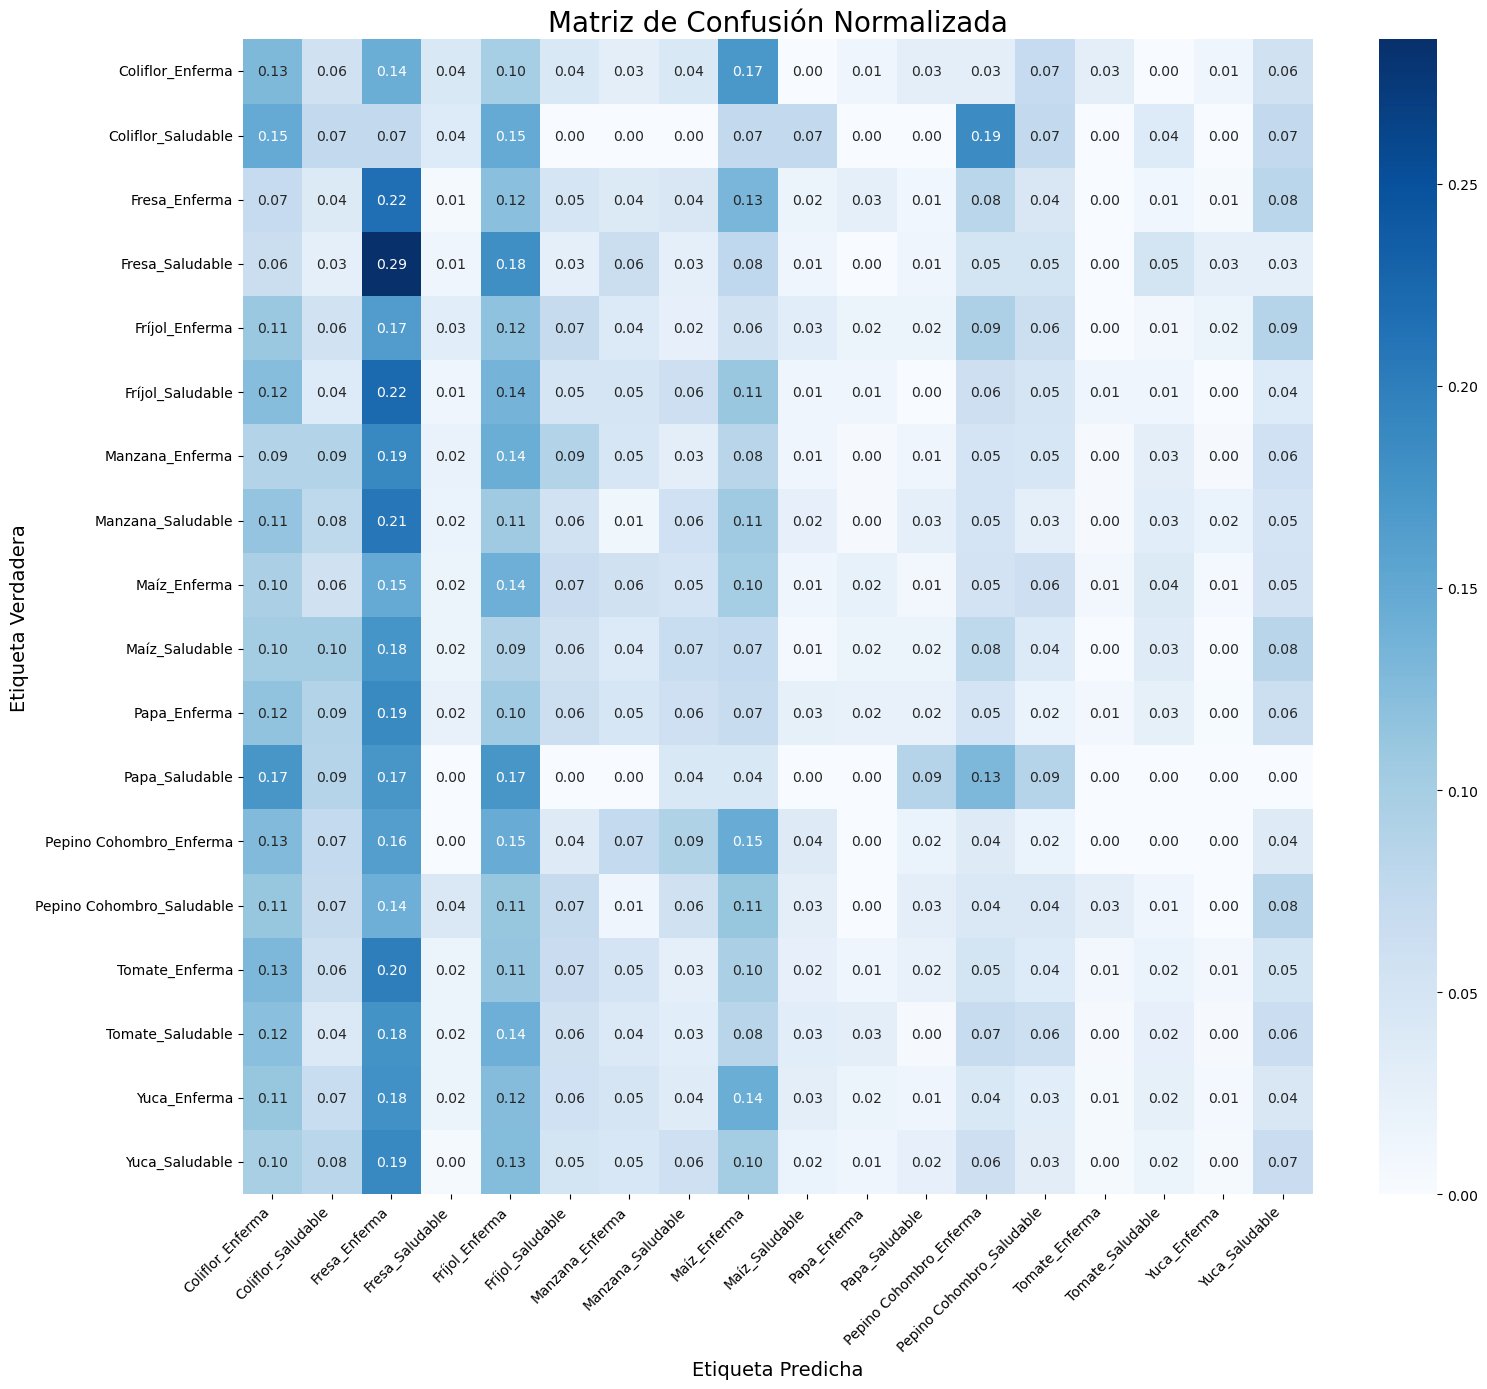


Reporte de Clasificación:
                           precision    recall  f1-score   support

         Coliflor_Enferma     0.0211    0.1286    0.0362        70
       Coliflor_Saludable     0.0075    0.0741    0.0137        27
            Fresa_Enferma     0.0539    0.2155    0.0862       181
          Fresa_Saludable     0.0154    0.0130    0.0141        77
           Fríjol_Enferma     0.0309    0.1181    0.0489       127
         Fríjol_Saludable     0.0171    0.0494    0.0254        81
          Manzana_Enferma     0.0632    0.0462    0.0534       238
        Manzana_Saludable     0.0862    0.0591    0.0701       254
             Maíz_Enferma     0.1097    0.1005    0.1049       438
           Maíz_Saludable     0.0119    0.0056    0.0077       177
             Papa_Enferma     0.1129    0.0222    0.0370       316
           Papa_Saludable     0.0303    0.0870    0.0449        23
  Pepino Cohombro_Enferma     0.0089    0.0364    0.0143        55
Pepino Cohombro_Saludable     0.01

In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# 1. Predecir clases sobre el test set
# Obtener las predicciones del modelo
y_pred_probs = model.predict(test_generator, steps=len(test_generator), verbose=1)

# Convertir probabilidades a etiquetas (argmax)
y_pred = np.argmax(y_pred_probs, axis=1)

# 2. Obtener etiquetas verdaderas
# Las verdaderas etiquetas están en test_generator.classes
y_true = test_generator.classes

# 3. Obtener los nombres de las clases
class_labels = list(test_generator.class_indices.keys())

# 4. Calcular la matriz de confusión
cm = confusion_matrix(y_true, y_pred)

# 5. Normalizar la matriz de confusión (opcional para mejor visualización)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# 6. Graficar la matriz de confusión
plt.figure(figsize=(16, 14))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Matriz de Confusión Normalizada', fontsize=20)
plt.ylabel('Etiqueta Verdadera', fontsize=14)
plt.xlabel('Etiqueta Predicha', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 7. Reporte de clasificación (precisión, recall, f1-score por clase)
print('\nReporte de Clasificación:')
print(classification_report(y_true, y_pred, target_names=class_labels, digits=4))


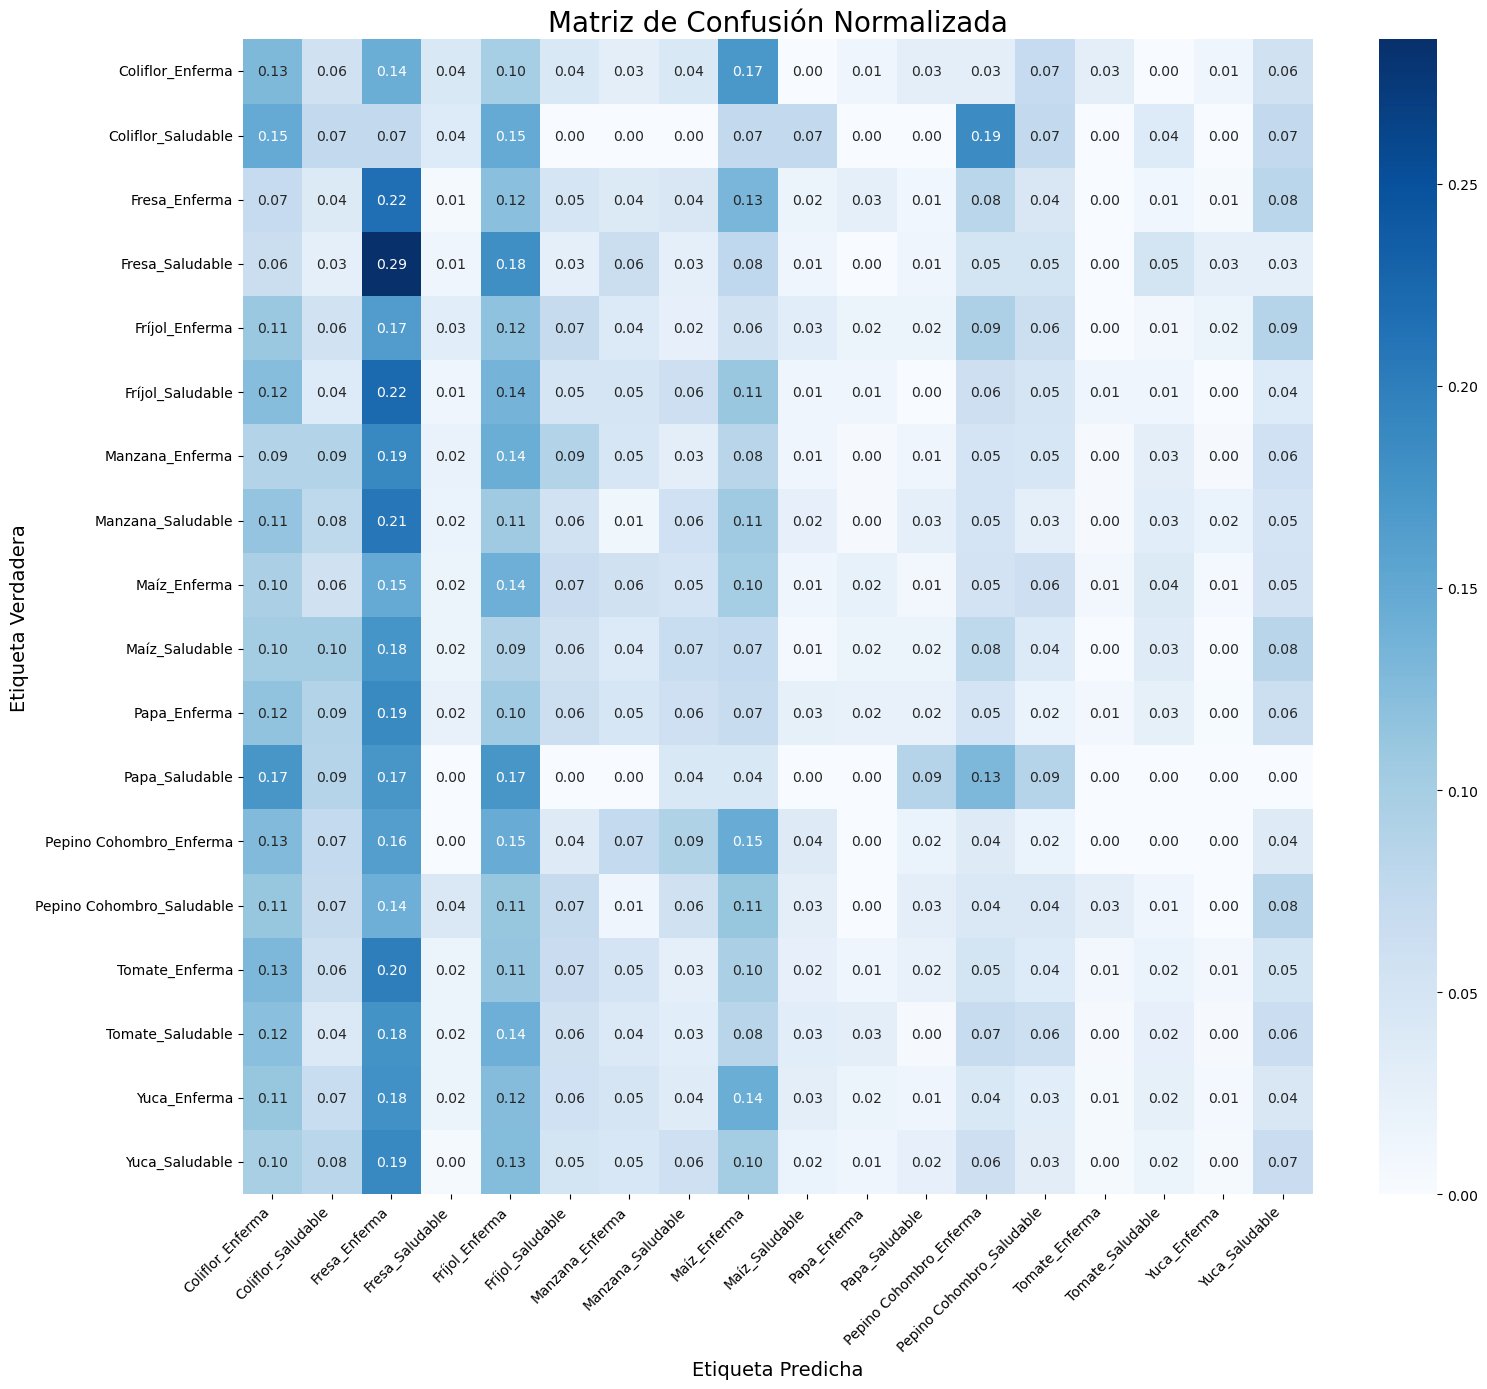

In [84]:
# 1. Guardar la figura de la matriz de confusión
plt.figure(figsize=(16, 14))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Matriz de Confusión Normalizada', fontsize=20)
plt.ylabel('Etiqueta Verdadera', fontsize=14)
plt.xlabel('Etiqueta Predicha', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# Guardar el gráfico como imagen
plt.savefig(r'C:\Proyecto de grado\Modelos\matriz_confusion.png', dpi=300)
plt.show()


In [86]:
# 2. Guardar el reporte de clasificación en CSV

# Convertir el reporte a un diccionario
from sklearn.metrics import classification_report

report = classification_report(y_true, y_pred, target_names=class_labels, output_dict=True)

# Convertirlo a DataFrame
report_df = pd.DataFrame(report).transpose()

# Guardar como CSV
report_df.to_csv(r'C:\Proyecto de grado\Modelos\reporte_clasificacion.csv', index=True)

print("✅ Reporte de clasificación guardado en C:\\Proyecto de grado\\Modelos\\reporte_clasificacion.csv")


✅ Reporte de clasificación guardado en C:\Proyecto de grado\Modelos\reporte_clasificacion.csv


In [88]:
accuracy = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.0505


In [102]:
# -------------------------
# 1. Obtener predicciones completas para test
# -------------------------
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

262/262 ━━━━━━━━━━━━━━━━━━━━ 91s 346ms/step


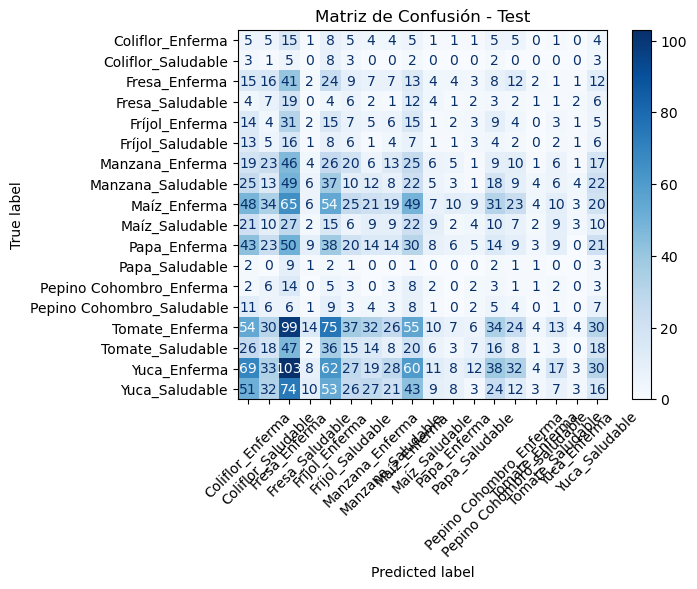

In [105]:
# -------------------------
# 2. Matriz de Confusión
# -------------------------
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_generator.class_indices.keys())
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Matriz de Confusión - Test")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step


ValueError: num must be an integer with 1 <= num <= 12, not 13

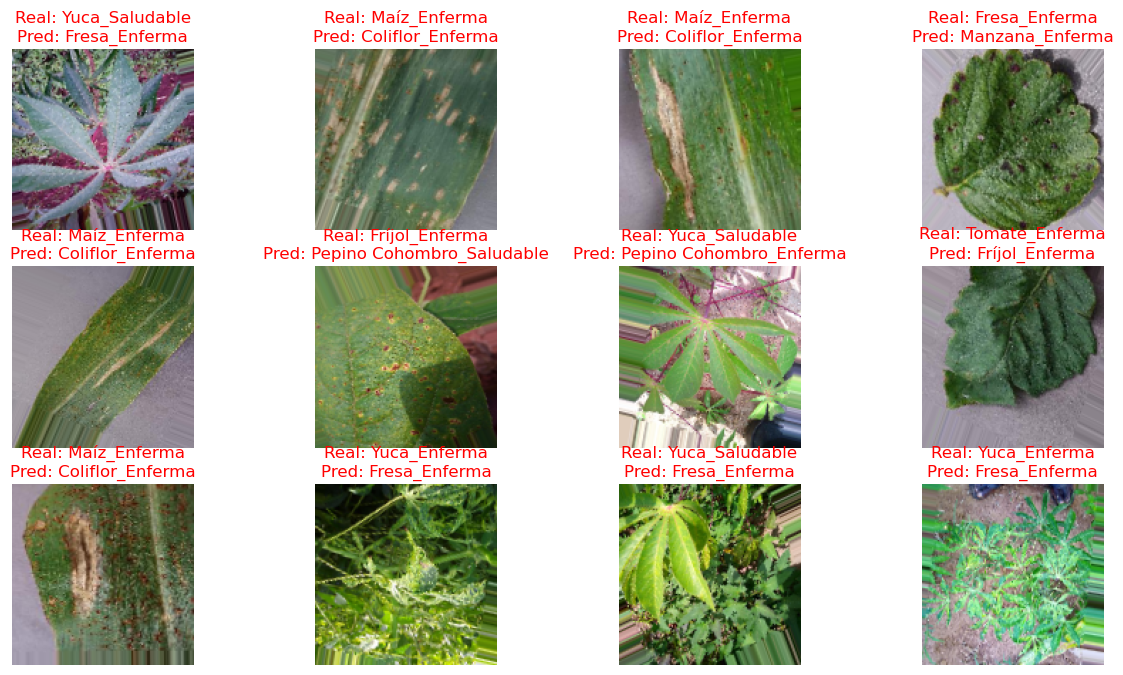

In [108]:
# Función para normalizar imágenes solo para visualización
def normalize_for_display(img):
    img_min = img.min()
    img_max = img.max()
    if img_max > 1.0 or img_min < 0.0:
        img = (img - img_min) / (img_max - img_min + 1e-7)
    return img

# Obtener nombres de clases
class_indices = test_generator.class_indices
class_names = list(class_indices.keys())

# Reiniciar el generador para empezar desde el principio
test_generator.reset()
x_batch, y_true_batch = next(test_generator)

# Obtener predicciones del modelo
y_pred_probs_batch = model.predict(x_batch)
y_pred_batch = np.argmax(y_pred_probs_batch, axis=1)
y_true_batch = np.argmax(y_true_batch, axis=1)

# Número de imágenes a mostrar (máximo el tamaño del batch)
num_samples = x_batch.shape[0]

# Mostrar imágenes con etiquetas
plt.figure(figsize=(15, 8))
for i in range(num_samples):
    plt.subplot(3, 4, i + 1)
    img_to_show = normalize_for_display(x_batch[i])
    plt.imshow(img_to_show)
    plt.axis('off')
    plt.title(
        f"Real: {class_names[y_true_batch[i]]}\nPred: {class_names[y_pred_batch[i]]}",
        color='green' if y_true_batch[i] == y_pred_batch[i] else 'red'
    )
plt.tight_layout()
plt.suptitle("Muestreo de Predicciones vs. Etiquetas Reales", fontsize=16, y=1.02)
plt.show()

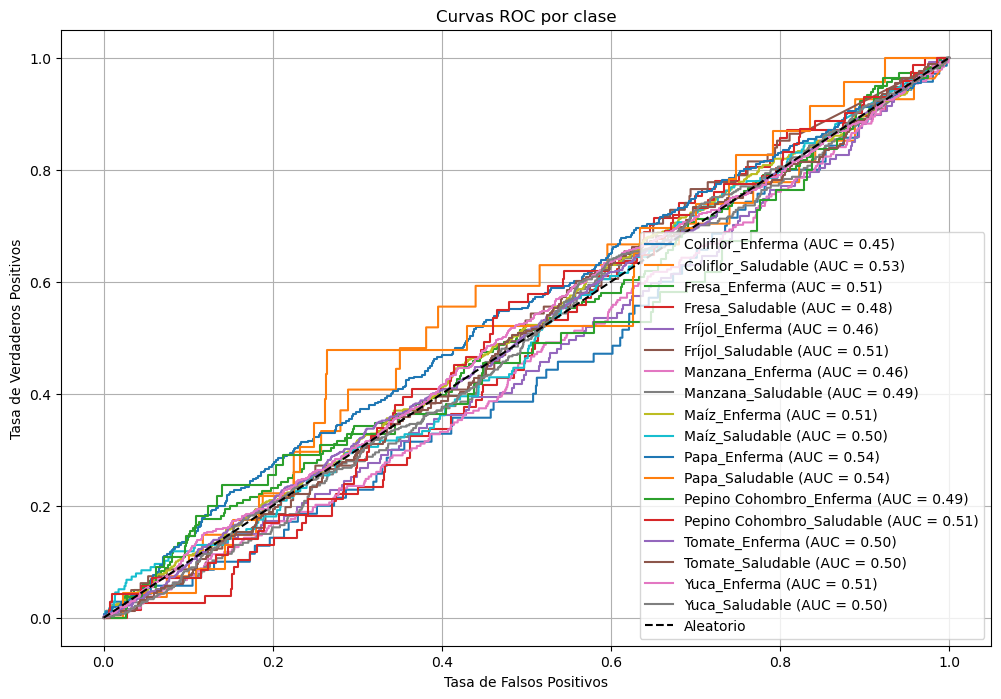

In [117]:
from sklearn.metrics import roc_curve, auc
from tensorflow.keras.utils import to_categorical

# 3. Convertir etiquetas reales a one-hot
n_classes = y_pred_probs.shape[1]
y_true_onehot = to_categorical(y_true, num_classes=n_classes)

# 4. Calcular ROC y AUC por clase
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_onehot[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 5. Obtener nombres de clase
class_names = list(test_generator.class_indices.keys())

# 6. Graficar curvas ROC
plt.figure(figsize=(12, 8))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Aleatorio')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curvas ROC por clase')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [122]:
from sklearn.metrics import roc_auc_score

# AUC macro (promedio de clases, todas igual de importantes)
auc_macro = roc_auc_score(y_true_onehot, y_pred_probs, average='macro')

# AUC micro (promedia sobre todas las instancias)
auc_micro = roc_auc_score(y_true_onehot, y_pred_probs, average='micro')

print(f"AUC Macro promedio: {auc_macro:.4f}")
print(f"AUC Micro promedio: {auc_micro:.4f}")


AUC Macro promedio: 0.5000
AUC Micro promedio: 0.4788


In [125]:
# Asegúrate de tener esto:
# y_pred = np.argmax(y_pred_probs, axis=1)
# y_true = test_generator.classes

# Accuracy
accuracy = accuracy_score(y_true, y_pred)

# F1 Scores
f1_macro = f1_score(y_true, y_pred, average='macro')
f1_micro = f1_score(y_true, y_pred, average='micro')
f1_weighted = f1_score(y_true, y_pred, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score (macro): {f1_macro:.4f}")
print(f"F1 Score (micro): {f1_micro:.4f}")
print(f"F1 Score (weighted): {f1_weighted:.4f}")

# Detalle por clase
class_names = list(test_generator.class_indices.keys())
print("\nReporte de clasificación por clase:")
print(classification_report(y_true, y_pred, target_names=class_names))

Accuracy: 0.0456
F1 Score (macro): 0.0353
F1 Score (micro): 0.0456
F1 Score (weighted): 0.0406

Reporte de clasificación por clase:
                           precision    recall  f1-score   support

         Coliflor_Enferma       0.01      0.07      0.02        70
       Coliflor_Saludable       0.00      0.04      0.01        27
            Fresa_Enferma       0.06      0.23      0.09       181
          Fresa_Saludable       0.00      0.00      0.00        77
           Fríjol_Enferma       0.03      0.12      0.05       127
         Fríjol_Saludable       0.03      0.07      0.04        81
          Manzana_Enferma       0.03      0.03      0.03       238
        Manzana_Saludable       0.05      0.03      0.04       254
             Maíz_Enferma       0.12      0.11      0.12       438
           Maíz_Saludable       0.11      0.05      0.07       177
             Papa_Enferma       0.10      0.02      0.03       316
           Papa_Saludable       0.00      0.00      0.00       

## 8. Guardar el modelo entrenado

In [130]:
model.save('modelo_15_Unet_PlantaEstado_Balanceado.h5')

In [133]:
fin = datetime.datetime.now()
print(f"Fin: {fin.strftime('%Y-%m-%d %H:%M:%S.%f')}")
    
duracion = fin - inicio
print(f"Duración: {duracion}")

Fin: 2025-05-18 20:56:18.569102
Duración: 10:43:21.211292


In [140]:
class_indices = train_generator.class_indices  # o test_generator.class_indices
index_to_class = {v: k for k, v in class_indices.items()}
print(index_to_class)
with open("index_to_class_modelo15.json", "w") as f:
    json.dump(index_to_class, f, indent=4, ensure_ascii=False)

{0: 'Maíz_Enferma', 1: 'Tomate_Saludable', 2: 'Yuca_Enferma', 3: 'Pepino Cohombro_Enferma', 4: 'Tomate_Enferma', 5: 'Manzana_Saludable', 6: 'Fresa_Enferma', 7: 'Maíz_Saludable', 8: 'Papa_Enferma', 9: 'Fresa_Saludable', 10: 'Coliflor_Enferma', 11: 'Pepino Cohombro_Saludable', 12: 'Yuca_Saludable', 13: 'Fríjol_Enferma', 14: 'Papa_Saludable', 15: 'Fríjol_Saludable', 16: 'Coliflor_Saludable', 17: 'Manzana_Enferma'}
